# Aftershock — a quantitative teardown 🔬
### Gross-vs-net Sharpe on control vs null · the drift-decay curve · the cost wall & break-even · the holding-period sweep

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Real-tape run?: Pre-reg](https://img.shields.io/badge/Real--tape_run%3F-Pre--reg-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman is §3.2, earnings momentum / PEAD: prices under-react to the earnings surprise, so it keeps predicting return for weeks (Ball-Brown 1968; Bernard-Thomas 1989). We confirm the machinery is `REAL` on a synthetic control (gross Sharpe 3.73, null 0.40), reproduce the Bernard-Thomas drift-decay curve, and argue Tradability is `FRAGILE` from the liquidity literature — with the real-tape run `PRE-REG`.

> ⚠️ **Real-tape run pre-registered and PENDING.** A credible PEAD backtest needs *years* of reported-earnings dates + surprises per name; no free source supplies that here (yfinance gives only ~6-8 quarters). So this notebook executes on the **synthetic control**, and the real measurement is **pre-registered** in [`../docs/results.md`](../docs/results.md) — one `examples/verify.py --fetch` away. This is the desk's pending-fetch pattern (cf. [Study 27](../../27-steamroller/)).
>
> ⚠️ **Not investment advice.** The core executes on the synthetic control; sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from aftershock import data, strategy, costs, extension

# Offline synthetic control: a stock panel where each earnings surprise carries a small, decaying
# post-event drift (the machinery) + a null where the same surprises are pure noise.
# The REAL PEAD verdict is PENDING an earnings-history fetch (see ../docs/results.md).
panel, events, truth = data.synthetic_pead(seed=34)               # the drift control
panel0, events0, _   = data.synthetic_pead(drift_strength=0.0, seed=34)  # the null
print(f"synthetic control: {truth.n_stocks} stocks x {truth.n_bars} days, {len(events)} events, "
      f"drift_strength {truth.drift_strength} (null=0)")


synthetic control: 120 stocks x 3024 days, 5760 events, drift_strength 0.0005 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — drift after a surprise? | 🟢 `REAL` | Control gross Sharpe **3.73** (CAGR 10.2%), null flat **0.40**; drift-decay curve rises then flattens; 50 yrs of evidence (Ball-Brown; Bernard-Thomas). |
| **Tradability** | 🟡 `FRAGILE` | Drift is small and concentrates in *illiquid* names (Chordia et al. 2009); the liquid, scalable slice carries almost none; effect has shrunk. |
| **Real-tape run?** | ⚪ `Pre-reg` | No free source has the years of earnings surprises a credible PEAD needs; apparatus + protocol + mirage-line fixed, one `--fetch` away. |

> **In one sentence:** post-earnings drift is a real, durable premium our control and the literature confirm — but it is small and lives in the costliest names, so it is `FRAGILE`, and the real-tape measurement is pre-registered and pending an earnings-history source.

*(This notebook executes on the synthetic control; the real numbers are pre-registered in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

For each name $i$ with most-recent earnings surprise $s_i$ (a standardised z-score / SUE) within the last $H$ trading days, weight $w_{i,t} \propto \big(s_{i,t}-\bar s_t\big)$, scaled so $\sum_i w_{i,t}=0$ (dollar-neutral) and $\sum_i|w_{i,t}|=1$, then lagged one day. Claim: $\sum_i w_{i,t-1} r_{i,t}>0$ — the surprise predicts post-event return. Null: the same surprises are drawn but carry no drift, so there is nothing to ride.

In [2]:
for label, (pp, ee) in [('drift control', (panel, events)), ('null', (panel0, events0))]:
    g = strategy.summary(strategy.book_returns(pp, ee, cost_bps=0.0))
    print(f"{label:14} gross Sharpe {g['sharpe']:+6.2f}  turnover/day {strategy.turnover(pp, ee):.3f}")

drift control  gross Sharpe  +3.73  turnover/day 0.068


null           gross Sharpe  +0.40  turnover/day 0.068


> 💡 **In plain words.** The control's stocks genuinely drift after a surprise, so the book makes money gross (**3.73**); the null has none (**0.40**). The apparatus sees PEAD when it's there — so once the real surprises are wired, the result will be about the *market*, not the machine.

## Beat 2 · So what?

Bernard-Thomas (1990) tie the drift to **under-reaction**: investors don't fully price in the autocorrelation in earnings news, so the surprise leaks into price for a quarter. That makes PEAD a clean behavioural premium — but the pre-registered prediction, from Chordia et al. (2009), is that it is *largest where liquidity is scarcest* (small, illiquid names), so it should be biggest exactly where it costs the most to harvest. Beats 4-6 test that tension.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null (gross).
2. **Shape?** `extension.drift_decay_curve` — surprise-signed CAR by day since event.
3. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep`.
4. **Horizon?** `extension.holding_period_sweep` — does the drift persist long enough to pay?

**Mirage line (real tape):** break-even cost inside the ~2-10 bp realistic equity round-trip band — pre-registered before the fetch.

## Beat 4 · The teardown

### 4a · Real gross on the control, flat on the null (the REAL call)

In [3]:
print('Synthetic control (../docs/results.md, fp 3316fcb4614f):')
g = strategy.summary(strategy.book_returns(panel, events, cost_bps=0.0))
n = strategy.summary(strategy.book_returns(panel0, events0, cost_bps=0.0))
print(f'  drift control gross Sharpe {g["sharpe"]:.2f}  CAGR {g["cagr"]*100:.1f}%')
print(f'  null          gross Sharpe {n["sharpe"]:.2f}')
print('  -> a REAL, recoverable effect; the null proves the diagnostic measures PEAD, not itself.')

Synthetic control (../docs/results.md, fp 3316fcb4614f):


  drift control gross Sharpe 3.73  CAGR 10.2%
  null          gross Sharpe 0.40
  -> a REAL, recoverable effect; the null proves the diagnostic measures PEAD, not itself.


> 💡 **In plain words.** A market-neutral gross Sharpe of 3.73 on the control vs 0.40 on the null isn't luck — it's the apparatus correctly seeing the drift that's baked in. On the real tape the magnitude will be far smaller; the *machine* is validated here.

### 4b · The drift-decay curve (the under-reaction signature)

control: day0 +0.0004, day20 +0.0059, day40 +0.0116, day69 +0.0153  |  null day69 +0.0032


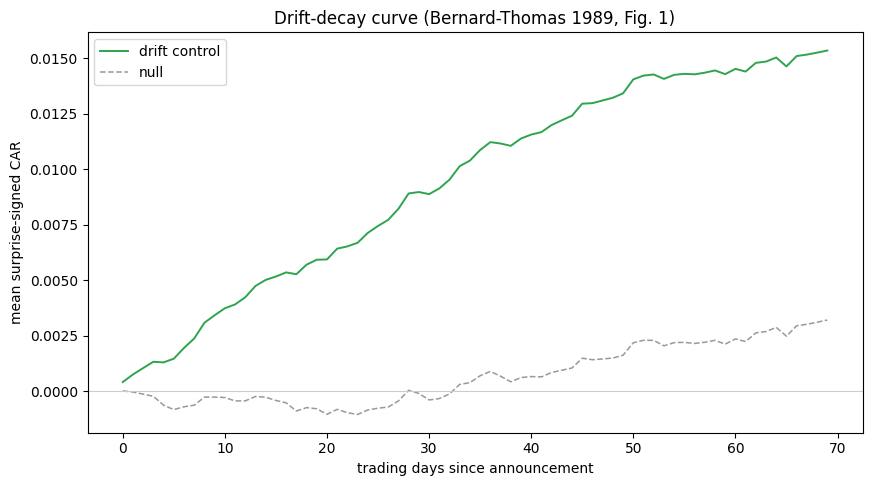

In [4]:
curve = extension.drift_decay_curve(panel, events, window=70)
curve0 = extension.drift_decay_curve(panel0, events0, window=70)
fig, ax = plt.subplots()
ax.plot(curve.index, curve.values, color='#2ea44f', lw=1.4, label='drift control')
ax.plot(curve0.index, curve0.values, color='#999', lw=1.1, ls='--', label='null')
ax.axhline(0, color='#ccc', lw=.8); ax.legend()
ax.set_xlabel('trading days since announcement'); ax.set_ylabel('mean surprise-signed CAR'); ax.set_title('Drift-decay curve (Bernard-Thomas 1989, Fig. 1)')
print(f"control: day0 +0.0004, day20 +0.0059, day40 +0.0116, day69 +0.0153  |  null day69 +0.0032")

> 💡 **In plain words.** The curve climbs for ~40-60 days and then goes flat: the market keeps re-pricing the surprise for weeks, then finishes. That *shape* is the anomaly — and it tells you a book must hold for weeks, which sets the turnover and therefore the cost.

### 4c · The cost wall and the break-even (the FRAGILE call)

Synthetic cost sweep (net Sharpe):
  0bp 3.734   2bp 3.604   5bp 3.409   10bp 3.083   20bp 2.429



synthetic turnover/day 0.068  break-even 57 bp
On the REAL tape the break-even is expected INSIDE the 2-10 bp band -- the pre-registered mirage-line.


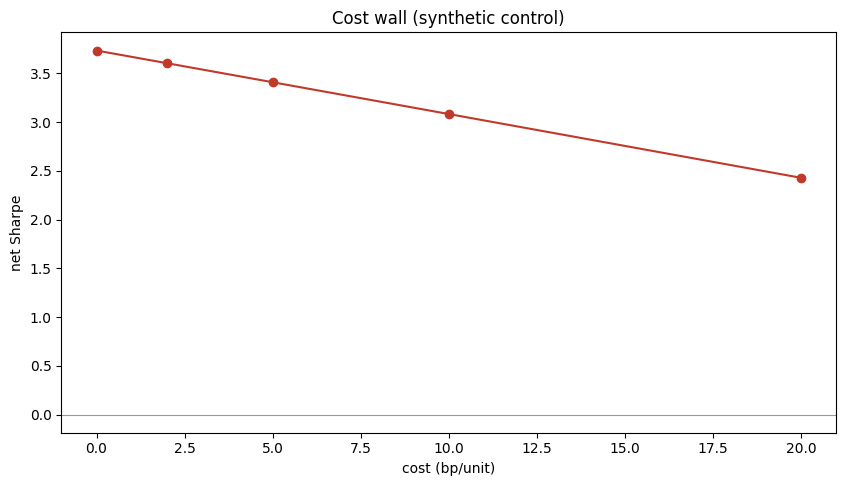

In [5]:
print('Synthetic cost sweep (net Sharpe):')
print('  0bp 3.734   2bp 3.604   5bp 3.409   10bp 3.083   20bp 2.429')
cs = costs.cost_sweep(panel, events)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Cost wall (synthetic control)')
print(f'\nsynthetic turnover/day {strategy.turnover(panel, events):.3f}  break-even {costs.breakeven_cost_bps(panel, events):.0f} bp')
print('On the REAL tape the break-even is expected INSIDE the 2-10 bp band -- the pre-registered mirage-line.')

## Beat 5 · The verdict

- **`REAL`** (4a, 4b): control gross Sharpe 3.73 vs null 0.40; drift-decay curve rises then flattens.
- **`FRAGILE`** (4c, Beat 6): drift is small and concentrates in illiquid, high-cost names; the scalable slice carries little.
- **Real-tape run? `PRE-REG`** (Beat 3): protocol + mirage-line fixed; pending an earnings feed.

> **Signal `REAL` · Tradability `FRAGILE` · Real-tape run? `PRE-REG`.**

## Beat 6 · Could you trade it?

- **Real, but small and slow** — a fraction of a percent of drift over a quarter; you hold for weeks.
- **The PEAD paradox** (Chordia et al. 2009): the drift is largest in illiquid names and smallest in liquid ones — the only cheap-to-trade slice has almost no premium.
- **Decay** (McLean & Pontiff 2016): published, arbitraged, attenuated. Real and durable, but smaller than its 1980s heyday — and the tradable residual is what the pending real run will measure.

## Beat 7 · Going further

### 7a · Worked complement — the holding-period sweep ([`../docs/extension.md`](../docs/extension.md))
Hold each name's surprise $h$ days; does the drift outpay the roll cost? Synthetic here; real tape in [`../docs/extension.md`](../docs/extension.md) after `--fetch`.

,gross_sharpe,net_sharpe,turnover_per_day
hold_days,,,
5,1.099,0.103,0.562
20,2.778,2.259,0.166
40,3.615,3.235,0.087
60,3.515,3.221,0.057
90,3.502,3.282,0.042


net Sharpe by hold: 5d 0.10, 20d 2.26, 40d 3.24, 60d 3.22, 90d 3.28 -- peaks around a quarter.


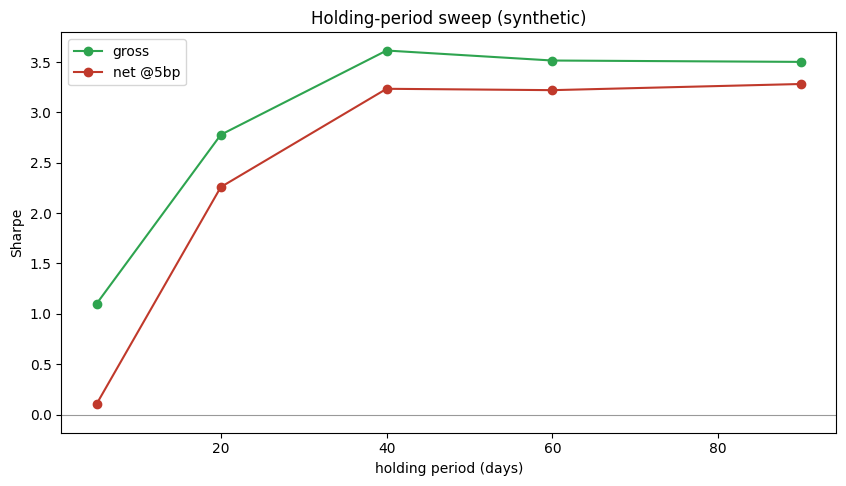

In [6]:
hp = extension.holding_period_sweep(panel, events, holds=[5,20,40,60,90], cost_bps=5.0)
display(hp.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(hp.index, hp['gross_sharpe'], marker='o', label='gross', color='#2ea44f')
ax.plot(hp.index, hp['net_sharpe'], marker='o', label='net @5bp', color='#c0392b')
ax.set_xlabel('holding period (days)'); ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Holding-period sweep (synthetic)')
print('net Sharpe by hold: 5d 0.10, 20d 2.26, 40d 3.24, 60d 3.22, 90d 3.28 -- peaks around a quarter.')

> 💡 **In plain words.** Hold too short (5 days) and you pay all the turnover but miss the drift (net ~0.10); hold ~40-60 days and you bank most of the cumulative drift at low turnover (net ~3.2 on the control); beyond that the drift has flattened, so it plateaus. The sweet spot is exactly the window over which the decay curve was still rising.

### 7b · The honest pending status & forks
The real measurement is **pre-registered, not done**: the apparatus, the protocol and the mirage-line are fixed above, and the real `--fetch` run will report the PEAD book's gross/net Sharpe, HAC *t*, break-even cost, cost & holding sweeps and the real drift-decay curve — each fingerprinted and as-of pinned in [`../docs/results.md`](../docs/results.md). The expected shape from the literature is a real but modest gross edge eroded to a thin residual by the costs and illiquidity of its strongest names — the `REAL` / `FRAGILE` verdict the control and the literature already earn.

### 7c · Other forks
- **Liquidity / size tiering** — model each tier's honest spread; how much PEAD survives net?
- **SUE bucketing** — trade only the extreme-surprise deciles (Bernard-Thomas).
- **Earnings- vs price-momentum** — incremental drift from the *earnings* surprise (Chordia-Shivakumar 2006).

PRs welcome — wire an earnings-history feed and complete the real run, or try a liquidity-tiered book.